What should consider when preprocessing data?

1. Detect and remove duplicate entries from a dataset.
2. Apply appropriate strategies for handling missing values.
3. Perform basic feature engineering (new attributes, encoding).
4. Detect and handle outliers using statistical methods.
5. Standardize and normalize features to prepare for modeling.
6. Transform and encode features (e.g. Age groups) for improved model input.


Each exercise builds on the previous one — keep a consistent preprocessing narrative throughout the notebook. Also, be sure to comment your code to explain your decisions, especially when choosing thresholds or methods.



Tip: The recommended preprocessing sequence is:

1. Handle duplicates
2. Address missing values
3. Treat outliers
4. Encode categorical variables


For all of the below exercises, you will use the Titanic dataset (train.csv), so load it beforehand on your notebook.
You will notice in the following exercises that the dataset is already pretty clean but try and understand all of the functions used for preprocessing the data.
Optionally, if you have time and willing to, you can redo the exercises with a less clean dataset : Weather Data Munich 1954-2022.



In [1]:
# Exercise 1: Duplicate Detection and Removal
# Instructions
# Objective: Identify and remove duplicate entries in the Titanic dataset.

# Load the Titanic dataset.
# Identify if there are any duplicate rows based on all columns.
# Remove any duplicate rows found in the dataset.
# Verify the removal of duplicates by checking the number of rows before and after the duplicate removal.
# Hint: Use the duplicated() and drop_duplicates() functions in Pandas.

import pandas as pd
# Load the Titanic dataset
titanic_data = pd.read_csv('train.csv')
# Check for duplicate rows
duplicate_rows = titanic_data.duplicated()
print(f"Number of duplicate rows: {duplicate_rows.sum()}")
# Remove duplicate rows
titanic_data_cleaned = titanic_data.drop_duplicates()
# Verify the removal of duplicates
print(f"Number of rows before duplicate removal: {len(titanic_data)}")
print(f"Number of rows after duplicate removal: {len(titanic_data_cleaned)}")


Number of duplicate rows: 0
Number of rows before duplicate removal: 891
Number of rows after duplicate removal: 891


In [2]:
# Exercise 2: Handling Missing Values
# Instructions
# Identify columns in the Titanic dataset with missing values.
# Explore different strategies for handling missing data, such as removal, imputation, and filling with a constant value.
# Apply each strategy to different columns based on the nature of the data.
# Hint: Review methods like dropna(), fillna(), and SimpleImputer from scikit-learn.

# Identify columns with missing values
missing_values = titanic_data.isnull().sum()
print("Columns with missing values:")
print(missing_values[missing_values > 0])
# Strategy 1: Remove rows with missing values in the 'Age' column
titanic_data_no_age = titanic_data.dropna(subset=['Age'])
# Strategy 2: Impute missing values in the 'Age' column with the median age
median_age = titanic_data['Age'].median()
titanic_data_imputed_age = titanic_data.copy()
titanic_data_imputed_age['Age'].fillna(median_age, inplace=True)
# Strategy 3: Fill missing values in the 'Cabin' column with a constant value
titanic_data_filled_cabin = titanic_data.copy()
titanic_data_filled_cabin['Cabin'].fillna('Unknown', inplace=True)
# Verify the handling of missing values
print("After handling missing values:")
print(titanic_data_no_age.isnull().sum())
print(titanic_data_imputed_age.isnull().sum())
print(titanic_data_filled_cabin.isnull().sum())


Columns with missing values:
Age         177
Cabin       687
Embarked      2
dtype: int64
After handling missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          529
Embarked         2
dtype: int64
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


/var/folders/19/hgbcmn617pq67g3xhjzlxc2r0000gn/T/ipykernel_31770/3621023578.py:17: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  titanic_data_imputed_age['Age'].fillna(median_age, inplace=True)
/var/folders/19/hgbcmn617pq67g3xhjzlxc2r0000gn/T/ipykernel_31770/3621023578.py:20: ChainedAssignmentError: A value is being set on a copy of 

In [3]:
# Exercise 3: Feature Engineering
# Instructions
# Create new features, such as Family Size from SibSp and Parch, and Title extracted from the Name column.
# Convert categorical variables into numerical form using techniques like one-hot encoding or label encoding.
# You will encode new categorical features (like Title) here, but do not scale numerical features yet — that will come after outlier handling.
# Hint: Utilize Pandas for data manipulation and scikit-learn’s preprocessing module for encoding.

from sklearn.preprocessing import LabelEncoder

# Work on a copy so the original stays intact for later exercises
df = titanic_data.copy()

# --- New feature 1: FamilySize ---
# SibSp = # of siblings/spouses aboard, Parch = # of parents/children aboard.
# +1 to include the passenger themselves.
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Derived flag: traveling alone (often a useful signal for survival)
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# --- New feature 2: Title extracted from Name ---
# Names follow the pattern "Last, Title. First ..." — extract the token between ", " and "."
df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.', expand=False).str.strip()

# Group rare/equivalent titles to reduce noise and keep encoded space small
title_mapping = {
    'Mlle': 'Miss', 'Ms': 'Miss',
    'Mme': 'Mrs',
    'Lady': 'Rare', 'Countess': 'Rare', 'Capt': 'Rare', 'Col': 'Rare',
    'Don': 'Rare', 'Dr': 'Rare', 'Major': 'Rare', 'Rev': 'Rare',
    'Sir': 'Rare', 'Jonkheer': 'Rare', 'Dona': 'Rare',
}
df['Title'] = df['Title'].replace(title_mapping)

print("Title value counts:")
print(df['Title'].value_counts())

# --- Encode categorical variables ---
# Sex is binary -> label encoding is appropriate and compact
df['Sex'] = LabelEncoder().fit_transform(df['Sex'])  # female=0, male=1

# Embarked & Title are nominal with >2 categories -> one-hot encoding (no false ordering)
# Fill Embarked NaNs with the mode before encoding (only 2 missing values).
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = pd.get_dummies(df, columns=['Embarked', 'Title'], drop_first=True)

# Drop columns we no longer need for modeling (raw text / identifiers)
df = df.drop(columns=['Name', 'Ticket'])

# Save as the working dataframe for subsequent exercises
titanic_fe = df

print("\nShape after feature engineering:", titanic_fe.shape)
print("\nPreview:")
print(titanic_fe.head())


Title value counts:
Title
Mr              517
Miss            185
Mrs             126
Master           40
Rare             22
the Countess      1
Name: count, dtype: int64

Shape after feature engineering: (891, 18)

Preview:
   PassengerId  Survived  Pclass  Sex   Age  SibSp  Parch     Fare Cabin  \
0            1         0       3    1  22.0      1      0   7.2500   NaN   
1            2         1       1    0  38.0      1      0  71.2833   C85   
2            3         1       3    0  26.0      0      0   7.9250   NaN   
3            4         1       1    0  35.0      1      0  53.1000  C123   
4            5         0       3    1  35.0      0      0   8.0500   NaN   

   FamilySize  IsAlone  Embarked_Q  Embarked_S  Title_Miss  Title_Mr  \
0           2        0       False        True       False      True   
1           2        0       False       False       False     False   
2           1        1       False        True        True     False   
3           2        0       

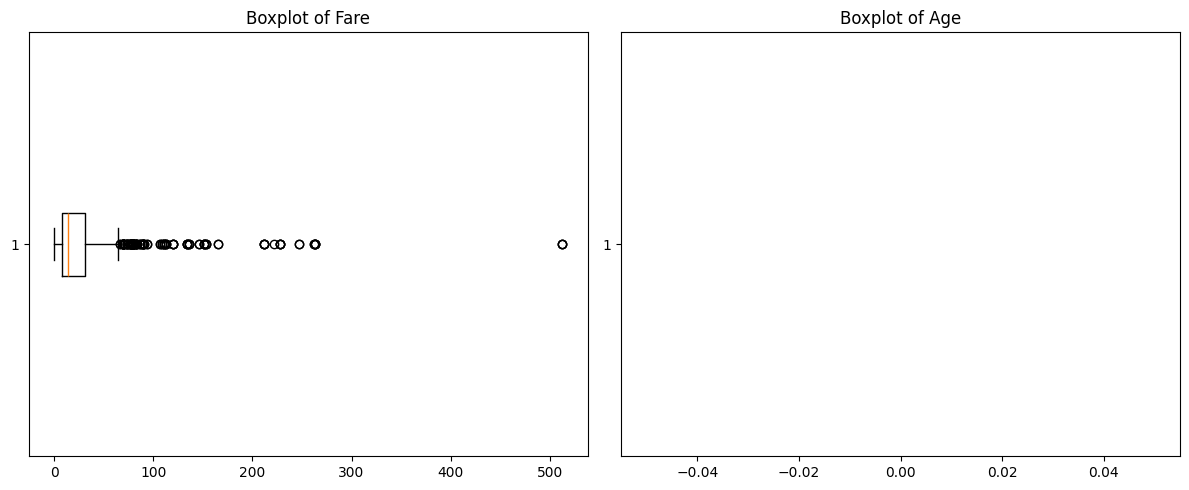

Number of outliers in Fare: 116
Number of outliers in Age: 11


In [4]:
# Exercise 4: Outlier Detection and Handling
# Goal: Detect and cap or transform outliers in columns like Fare and Age.

# 1. Visualize distributions using boxplots or histograms to identify potential outliers.
# 2. Use IQR or Z-score methods to detect them.
# 3. Handle outliers with:

# Quantile capping (e.g. 0.98)
# Log transformation
# Row removal
# 4. Compare the dataset before and after treatment.

# 📌 Note: Small differences between 0.98 and 0.99 quantiles are normal when extreme values are rare or far apart. Use df.quantile() to explore and choose thresholds empirically, backed by visualization.

import matplotlib.pyplot as plt
# Visualize distributions to identify potential outliers
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.boxplot(titanic_fe['Fare'], vert=False)
plt.title('Boxplot of Fare')
plt.subplot(1, 2, 2)
plt.boxplot(titanic_fe['Age'], vert=False)
plt.title('Boxplot of Age')
plt.tight_layout()
plt.show()
# Detect outliers using IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] < lower_bound) | (data[column] > upper_bound)]
outliers_fare = detect_outliers_iqr(titanic_fe, 'Fare')
outliers_age = detect_outliers_iqr(titanic_fe, 'Age')
print(f"Number of outliers in Fare: {len(outliers_fare)}")
print(f"Number of outliers in Age: {len(outliers_age)}")
# Handle outliers with quantile capping (e.g. 0.98)

fare_cap = titanic_fe['Fare'].quantile(0.98)
titanic_fe['Fare_capped'] = titanic_fe['Fare'].apply(lambda x: min(x, fare_cap))



In [5]:
# Exercise 5: Data Standardization and Normalization
# Goal: Scale numerical features to prepare for modeling.

# Use StandardScaler (mean = 0, std = 1) for normally distributed features.
# Use MinMaxScaler (range [0, 1]) for features that are skewed or bounded.
# 📌 Important: Perform this step after outlier treatment to avoid distortion caused by extreme values.

from sklearn.preprocessing import StandardScaler, MinMaxScaler
# Identify numerical features to scale (excluding target variable 'Survived')
numerical_features = ['Age', 'Fare_capped', 'FamilySize']
# Standardize normally distributed features (Age)
scaler_standard = StandardScaler()
titanic_fe['Age_scaled'] = scaler_standard.fit_transform(titanic_fe[['Age']])
# Normalize skewed features (Fare_capped, FamilySize)
scaler_minmax = MinMaxScaler()
titanic_fe['Fare_scaled'] = scaler_minmax.fit_transform(titanic_fe[['Fare_capped']])
titanic_fe['FamilySize_scaled'] = scaler_minmax.fit_transform(titanic_fe[['FamilySize']])
# Drop original columns after scaling
titanic_fe = titanic_fe.drop(columns=['Age', 'Fare_capped', 'FamilySize'])
print("Shape after scaling:", titanic_fe.shape)
print("\nPreview of scaled features:")
print(titanic_fe[['Age_scaled', 'Fare_scaled', 'FamilySize_scaled']].head())



Shape after scaling: (891, 19)

Preview of scaled features:
   Age_scaled  Fare_scaled  FamilySize_scaled
0   -0.530377     0.034305                0.1
1    0.571831     0.337296                0.1
2   -0.254825     0.037499                0.0
3    0.365167     0.251257                0.1
4    0.365167     0.038091                0.0


In [6]:
# Exercise 6: Feature Encoding
# Goal: Finalize categorical variable encoding.

# 1. Identify remaining categorical columns (e.g. Sex, Embarked, Title).
# 2. Apply:

# One-Hot Encoding for nominal variables.
# Label Encoding if any ordinal variables remain.
# 3. Merge encoded columns back into the main dataset.

# Reminder: Encoding comes after handling missing values and outliers, but before scaling (if applicable).

# Identify remaining categorical columns
categorical_columns = titanic_fe.select_dtypes(include=['object', 'category']).columns
print("Remaining categorical columns:", categorical_columns.tolist())
# One-Hot Encode remaining categorical variables (if any)
titanic_fe = pd.get_dummies(titanic_fe, columns=categorical_columns, drop_first=True)
print("Shape after final encoding:", titanic_fe.shape)
print("\nFinal dataset preview:")
print(titanic_fe.head())



Remaining categorical columns: ['Cabin']
Shape after final encoding: (891, 164)

Final dataset preview:
   PassengerId  Survived  Pclass  Sex  SibSp  Parch     Fare  IsAlone  \
0            1         0       3    1      1      0   7.2500        0   
1            2         1       1    0      1      0  71.2833        0   
2            3         1       3    0      0      0   7.9250        1   
3            4         1       1    0      1      0  53.1000        0   
4            5         0       3    1      0      0   8.0500        1   

   Embarked_Q  Embarked_S  ...  Cabin_E8  Cabin_F E69  Cabin_F G63  \
0       False        True  ...     False        False        False   
1       False       False  ...     False        False        False   
2       False        True  ...     False        False        False   
3       False        True  ...     False        False        False   
4       False        True  ...     False        False        False   

   Cabin_F G73  Cabin_F2  Cabin_F33 

/var/folders/19/hgbcmn617pq67g3xhjzlxc2r0000gn/T/ipykernel_31770/4191991338.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = titanic_fe.select_dtypes(include=['object', 'category']).columns


In [7]:
# Exercise 7: Data Transformation for Age Feature
# Goal: Create and encode age groups.

# Use pd.cut() to create bins for life stages (e.g. child, teen, adult, senior).
# Apply one-hot encoding using pd.get_dummies().
# Example: You might define bins like [0, 12, 18, 60, 100] and label them accordingly.

# Define age bins and labels
age_bins = [0, 12, 18, 60, 100]
age_labels = ['Child', 'Teen', 'Adult', 'Senior']
# Create age groups using pd.cut()
titanic_fe['AgeGroup'] = pd.cut(titanic_fe['Age_scaled'], bins=age_bins, labels=age_labels)
# One-Hot Encode the AgeGroup feature
titanic_fe = pd.get_dummies(titanic_fe, columns=['AgeGroup'], drop_first=True)
print("Shape after adding AgeGroup:", titanic_fe.shape)
print("\nPreview of AgeGroup encoding:")
print(titanic_fe.filter(like='AgeGroup').head())



Shape after adding AgeGroup: (891, 167)

Preview of AgeGroup encoding:
   AgeGroup_Teen  AgeGroup_Adult  AgeGroup_Senior
0          False           False            False
1          False           False            False
2          False           False            False
3          False           False            False
4          False           False            False
